# 22 — Apolonio sobre la cancha

El notebook 17 dibujó diagramas de Apolonio en un **espacio de perfil** (goles/90 contra asistencias/90) porque el
panel de FBref no trae posiciones. Este los lleva a la **cancha de verdad**, que es el uso original de los diagramas
ponderados en fútbol: la *dominant region* de Taki y Hasegawa (2000), donde el peso es la velocidad del jugador y
distancia/peso es el tiempo que tarda en llegar a cada punto.

Aquí no hay velocidades —los datos abiertos no traen seguimiento óptico— así que se usa lo que sí hay en los eventos
de **StatsBomb Open Data**: la posición media de cada jugador y cuántas acciones le salieron bien.

**Qué es cada cosa en este mapa**

- **Sitio**: la posición media de un jugador en un partido, sobre los eventos en que tocó el balón.
- **Peso**: sus acciones exitosas en ese partido (pases completados, conducciones, regates, recuperaciones, despejes,
  bloqueos, duelos ganados, tiros a puerta).
- **Celda**: la zona de la cancha para la que ese jugador es la referencia dominante, combinando cercanía y volumen.

**Dos advertencias que conviene leer antes que el mapa**

1. La posición media **no es dónde estuvo** el jugador: es el centro de sus acciones. Un lateral que sube y baja toda
   la banda aparece a media altura, en un punto donde quizá no estuvo nunca. Por eso se guarda también la dispersión.
2. El peso es participación con éxito, no calidad. Un mediocentro que toca 100 balones pesa más que un delantero que
   toca 25 y decide el partido. El área mide **territorio**, no rendimiento — la misma advertencia del notebook 17.

Con eso claro, la pregunta que sí se puede responder es la de siempre en este proyecto: **¿el territorio que domina un
jugador dice algo de él, o solo de su puesto?**

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from futbol_bd import apolonio, cancha, estilo

PROCESADOS = RAIZ / "data" / "processed"
FIGURAS = RAIZ / "output" / "figures" / "cancha"
FIGURAS.mkdir(parents=True, exist_ok=True)
estilo.aplicar()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)
# Las CUATRO temporadas que StatsBomb publica completas (todas 2015/16). El resto de su catálogo abierto son
# temporadas parciales de un equipo (la Premier 2003/04 es el Arsenal invicto; La Liga 2004-2021, el Barcelona).
LIGAS = {"laliga": "La Liga 2015/16", "premier": "Premier League 2015/16",
         "seriea": "Serie A 2015/16", "ligue1": "Ligue 1 2015/16"}

## 1. Los datos

`scripts/descargar_statsbomb_posiciones.py` baja los eventos de las dos temporadas completas que StatsBomb publica
con **todos** los partidos (La Liga y Premier League 2015/16, 380 cada una) y guarda solo el agregado por
jugador-partido: son ~8 MB de eventos por partido y de todo eso el análisis usa la posición media y el conteo de
acciones. La agregación vive en `futbol_bd/cancha.posiciones_por_partido`, la misma que usa este notebook.

In [2]:
posiciones, partidos = {}, {}
for clave, nombre in LIGAS.items():
    p = pd.read_csv(PROCESADOS / f"statsbomb_{clave}_posiciones.csv")
    p["liga"] = nombre
    # En los eventos StatsBomb trae el nombre legal completo ("Lionel Andrés Messi Cuccittini"); el nombre con el que
    # se le conoce está en las alineaciones y se bajó aparte.
    nombres = pd.read_csv(PROCESADOS / f"statsbomb_{clave}_jugadores.csv").set_index("player_id")["nombre"]
    p["nombre"] = p["player_id"].map(nombres).fillna(p["player"])
    # El área se calcula equipo por equipo: el mapa reparte la cancha ENTRE LOS ONCE de un mismo equipo.
    p["area"] = cancha.area_dominada(p[p["titular"]])
    posiciones[clave] = p
    partidos[clave] = pd.read_csv(PROCESADOS / f"statsbomb_{clave}_partidos.csv")
    print(f"{nombre}: {p['match_id'].nunique()} partidos, {len(p):,} filas jugador-partido, "
          f"{p['player_id'].nunique():,} jugadores")

TODO = pd.concat(posiciones.values(), ignore_index=True)
TODO["linea"] = TODO["posicion"].map(cancha.LINEA).fillna("Otro")
print(f"\nTitulares con área calculada: {TODO['area'].notna().sum():,}")
TODO[TODO["titular"]].groupby("linea")[["acciones", "exitosas", "x", "y", "x_desv", "y_desv"]].mean().round(1)

La Liga 2015/16: 380 partidos, 9,631 filas jugador-partido, 526 jugadores


Premier League 2015/16: 380 partidos, 9,498 filas jugador-partido, 519 jugadores


Serie A 2015/16: 380 partidos, 9,562 filas jugador-partido, 534 jugadores


Ligue 1 2015/16: 377 partidos, 9,521 filas jugador-partido, 546 jugadores

Titulares con área calculada: 33,208


,acciones,exitosas,x,y,x_desv,y_desv
linea,,,,,,
Ataque,77.9,58.6,76.0,39.8,23.2,19.7
Defensa,97.8,82.7,48.4,40.0,23.3,12.1
Medio,105.2,88.1,62.9,39.8,22.5,18.6
Portero,64.0,36.6,9.3,40.4,6.8,8.2


Las cuatro temporadas completas que publica StatsBomb —todas de 2015/16— suman 1,517 partidos. Son las únicas
de su catálogo abierto que sirven aquí: el resto son temporadas parciales centradas en un equipo (la Premier
2003/04 son los 38 partidos del Arsenal invicto; las 17 temporadas de La Liga entre 2004/05 y 2020/21 son los
partidos del Barcelona de Messi, unos 30 cada una). Las medias por línea ya dicen algo antes de dibujar nada: los
porteros actúan cerca de su portería y casi sin dispersión a lo ancho, los defensas en su propio campo, los medios en
el centro y los atacantes arriba. Y la dispersión es enorme en todos: entre 15 y 25 metros de desviación típica a lo
largo, en una cancha de 120. Ese número es el primer aviso de que la posición media es un resumen muy pobre de dónde
estuvo alguien.

## 2. El mapa de un partido

Un panel por equipo. Los dos se dibujan atacando de izquierda a derecha, que es como StatsBomb normaliza las
coordenadas: x = 0 es la portería propia y x = 120 la contraria.

Barcelona 1-2 Real Madrid · 2016-04-02


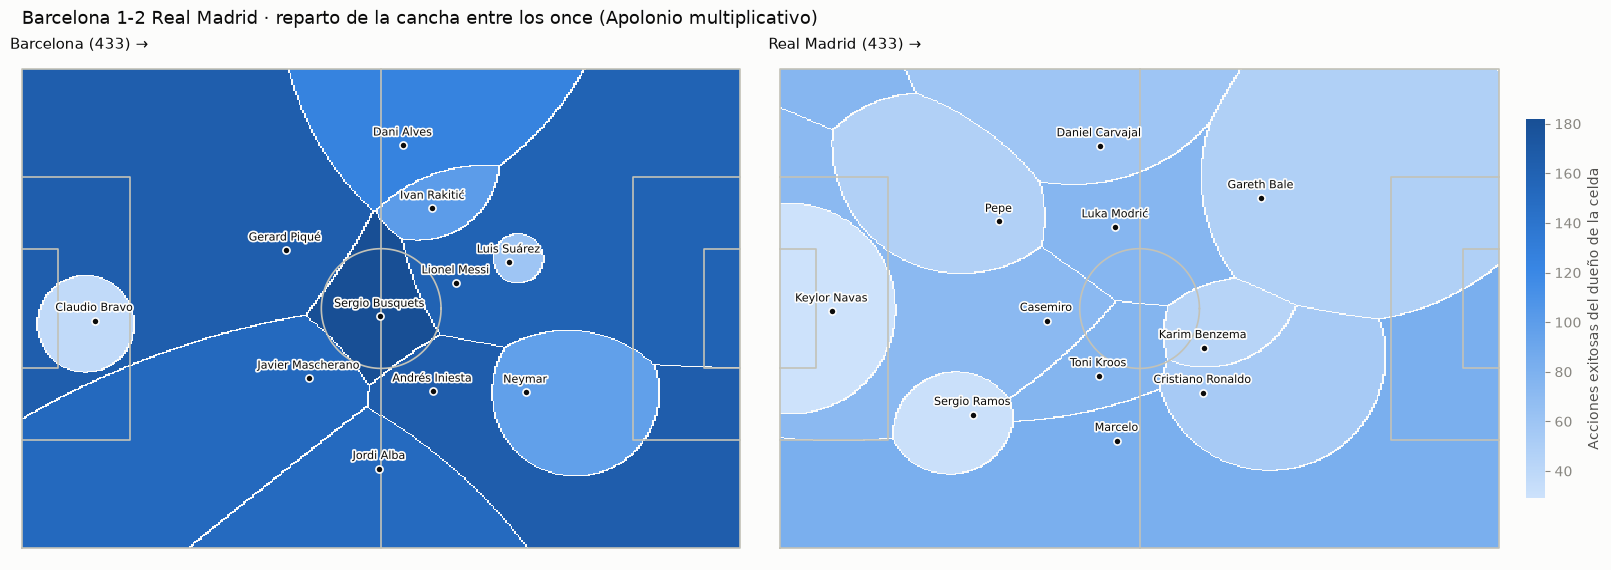

In [3]:
def etiqueta_corta(nombre):
    """El nombre ya es el apodo de la alineación cuando existe; si no, es el nombre legal y se corta por DELANTE.

    "Marco Asensio Willemsen" -> "Marco Asensio". Quedarse con la última palabra daría el segundo apellido, que es
    justo con el que no se conoce a nadie.
    """
    return nombre if len(nombre) <= 13 else " ".join(nombre.split()[:2])


def mapa_de_equipo(ax, sitios, norma, modo="multiplicativo", resolucion=400):
    """Dibuja las celdas de un equipo sobre una cancha, con el nombre de cada jugador en su punto."""
    etiquetas, xs, ys = apolonio.etiquetar(sitios[["x", "y"]].to_numpy(), sitios["peso"].to_numpy(),
                                           modo=modo, resolucion=resolucion, limites=cancha.LIMITES)
    apolonio.dibujar(ax, etiquetas, xs, ys, sitios["exitosas"].to_numpy(), estilo.RAMPA_AZUL, norma,
                     color_frontera=estilo.SUPERFICIE)
    cancha.dibujar_cancha(ax)
    ax.scatter(sitios["x"], sitios["y"], s=26, color=estilo.TINTA, edgecolors=estilo.SUPERFICIE, linewidths=1.2,
               zorder=5)
    for _, r in sitios.iterrows():
        ax.annotate(etiqueta_corta(r["nombre"]), (r["x"], r["y"]), xytext=(0, 7), textcoords="offset points",
                    ha="center", fontsize=8, color=estilo.TINTA, zorder=6,
                    path_effects=[__import__("matplotlib.patheffects", fromlist=["x"]).withStroke(
                        linewidth=2.5, foreground=estilo.SUPERFICIE)])


# Un partido reconocible: el Clásico de la temporada (y si no está, el de más goles).
pl, pa = posiciones["laliga"], partidos["laliga"]
clasico = pa[((pa["home_team"] == "Barcelona") & (pa["away_team"] == "Real Madrid"))
             | ((pa["home_team"] == "Real Madrid") & (pa["away_team"] == "Barcelona"))]
elegido = clasico.iloc[0] if len(clasico) else pa.assign(g=pa["home_score"] + pa["away_score"]).nlargest(1, "g").iloc[0]
MATCH = int(elegido["match_id"])
print(f"{elegido['home_team']} {elegido['home_score']}-{elegido['away_score']} {elegido['away_team']} "
      f"· {elegido['match_date']}")

equipos = [elegido["home_team"], elegido["away_team"]]
sitios = {e: cancha.sitios_de_equipo(pl, MATCH, e) for e in equipos}
norma = Normalize(min(s["exitosas"].min() for s in sitios.values()),
                  max(s["exitosas"].max() for s in sitios.values()))
fig, axs = plt.subplots(1, 2, figsize=(16, 5.6), constrained_layout=True)
for ax, equipo in zip(axs, equipos):
    mapa_de_equipo(ax, sitios[equipo], norma)
    ax.set_title(f"{equipo} ({sitios[equipo]['formacion'].iloc[0]}) →", loc="left")
barra = fig.colorbar(plt.cm.ScalarMappable(norm=norma, cmap=estilo.RAMPA_AZUL), ax=axs, shrink=0.75, pad=0.01)
barra.set_label("Acciones exitosas del dueño de la celda", color=estilo.TINTA_2)
barra.outline.set_visible(False)
fig.suptitle(f"{elegido['home_team']} {elegido['home_score']}-{elegido['away_score']} {elegido['away_team']}"
             f" · reparto de la cancha entre los once (Apolonio multiplicativo)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / "cancha_mapa_partido.png", dpi=150)
plt.show()

Así se reparte la cancha un equipo. Se lee bien lo que uno esperaría —el portero se queda con una franja estrecha
junto a su área, los centrales con el fondo, los medios con el centro— y también lo que no: las celdas **no** son
franjas ordenadas por líneas, sino regiones irregulares que se cruzan, porque el peso mueve las fronteras. Un
mediocentro con muchas acciones completadas se lleva terreno que "geométricamente" tocaría a un compañero más cercano.

Nótese que las fronteras son curvas, no rectas: son los círculos de Apolonio del modo multiplicativo. Un Voronoi
normal habría dado polígonos de lados rectos.

### Lo que el punto esconde: la dispersión

La posición media es un punto, pero el jugador se movió. Esta figura pone, sobre el mismo mapa, una elipse con una
desviación estándar de sus acciones a lo largo y a lo ancho. Si la elipse es grande, el punto (y por tanto su celda)
representa muy poco.

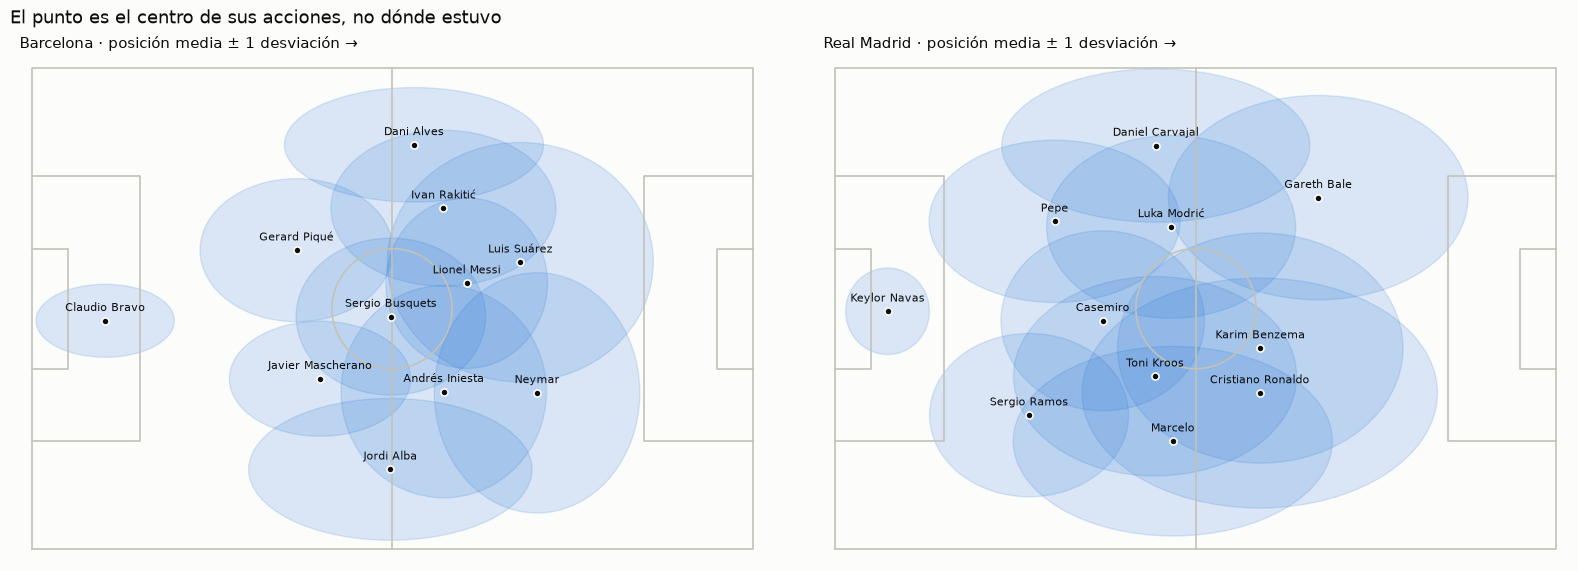

Dispersión media de Barcelona: 17 m a lo largo y 13 m a lo ancho, en una cancha de 120 × 80


In [4]:
from matplotlib.patches import Ellipse

fig, axs = plt.subplots(1, 2, figsize=(16, 5.6), constrained_layout=True)
for ax, equipo in zip(axs, equipos):
    s = sitios[equipo]
    cancha.dibujar_cancha(ax, color=estilo.EJE)
    for _, r in s.iterrows():
        ax.add_patch(Ellipse((r["x"], r["y"]), 2 * r["x_desv"], 2 * r["y_desv"], facecolor=estilo.AZUL, alpha=0.16,
                             edgecolor=estilo.AZUL, linewidth=1))
        ax.scatter(r["x"], r["y"], s=26, color=estilo.TINTA, edgecolors=estilo.SUPERFICIE, linewidths=1.2, zorder=5)
        ax.annotate(etiqueta_corta(r["nombre"]), (r["x"], r["y"]), xytext=(0, 7), textcoords="offset points",
                    ha="center", fontsize=8, color=estilo.TINTA, zorder=6)
    ax.set_title(f"{equipo} · posición media ± 1 desviación →", loc="left")
fig.suptitle("El punto es el centro de sus acciones, no dónde estuvo", x=0.01, ha="left", fontsize=13,
             color=estilo.TINTA)
fig.savefig(FIGURAS / "cancha_dispersion.png", dpi=150)
plt.show()

s = sitios[equipos[0]]
print(f"Dispersión media de {equipos[0]}: {s['x_desv'].mean():.0f} m a lo largo y {s['y_desv'].mean():.0f} m a lo "
      f"ancho, en una cancha de {cancha.LARGO:.0f} × {cancha.ANCHO:.0f}")

Esta es la figura que hay que mirar antes de creerse el mapa. Cada elipse cubre una desviación típica de las acciones
del jugador, y casi todas son gigantes: la mayoría abarca un tercio de la cancha. El punto que genera la celda es el
centro de una nube enorme, así que la celda describe **la zona donde ese jugador tuvo su centro de gravedad**, no un
territorio que ocupara de verdad.

Dicho de otra forma: el mapa es una buena manera de resumir cómo se repartió un equipo sus acciones, y una mala manera
de decir quién estaba dónde.

### Qué hace el peso

El mismo equipo repartido de dos formas: sin pesos (Voronoi normal, solo cuenta quién está más cerca) y con el peso de
las acciones exitosas. La diferencia es grande porque los pesos de un partido son muy desiguales —un mediocentro puede
completar 90 acciones y un delantero 15—, y el modo multiplicativo divide la distancia entre el peso.

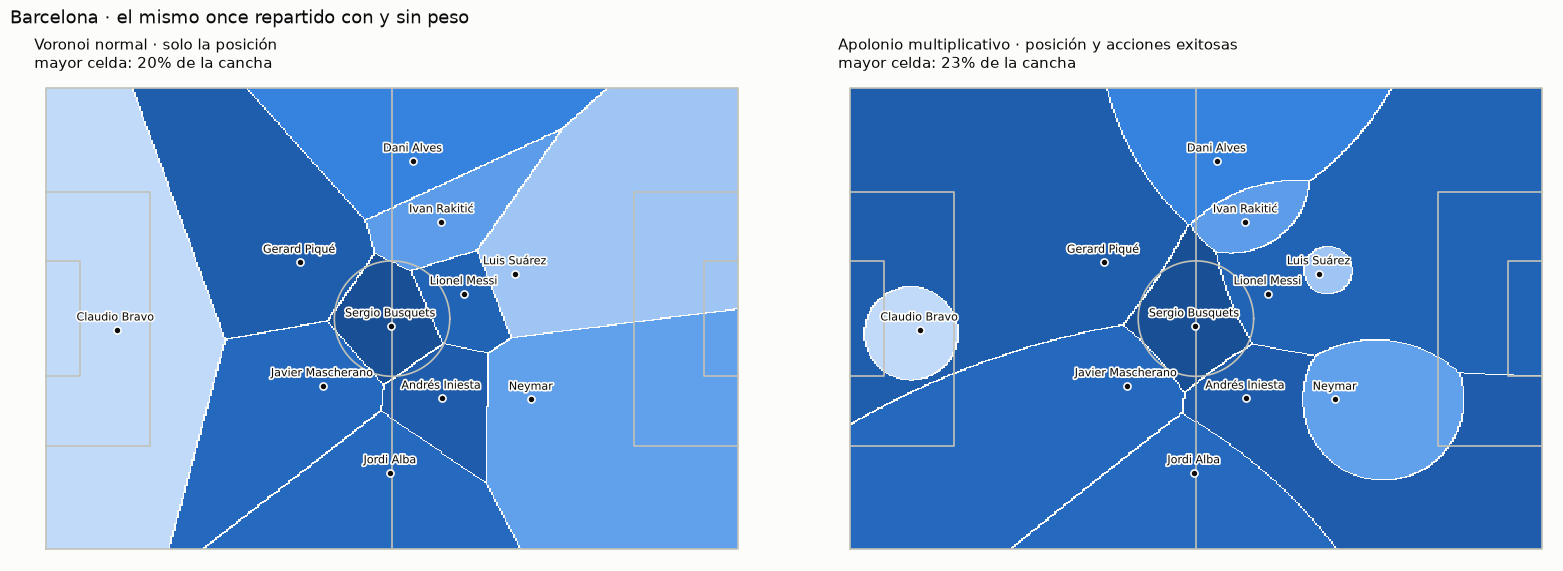

Acciones exitosas del once, de más a menos: Sergio Busquets 182, Andrés Iniesta 165, Gerard Piqué 164, Lionel Messi 159, Javier Mascherano 152, Jordi Alba 151, Dani Alves 125, Ivan Rakitić 100, Neymar 97, Luis Suárez 59, Claudio Bravo 37


In [5]:
equipo = equipos[0]
fig, axs = plt.subplots(1, 2, figsize=(16, 5.6), constrained_layout=True)
for ax, (modo, titulo) in zip(axs, [("voronoi", "Voronoi normal · solo la posición"),
                                    ("multiplicativo", "Apolonio multiplicativo · posición y acciones exitosas")]):
    mapa_de_equipo(ax, sitios[equipo], norma, modo=modo)
    et, _, _ = apolonio.etiquetar(sitios[equipo][["x", "y"]].to_numpy(), sitios[equipo]["peso"].to_numpy(),
                                  modo=modo, resolucion=400, limites=cancha.LIMITES)
    areas_modo = apolonio.areas(et, len(sitios[equipo]))
    ax.set_title(f"{titulo}\nmayor celda: {100 * areas_modo.max():.0f}% de la cancha", loc="left")
fig.suptitle(f"{equipo} · el mismo once repartido con y sin peso", x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / "cancha_efecto_del_peso.png", dpi=150)
plt.show()

print("Acciones exitosas del once, de más a menos:",
      ", ".join(f"{r.nombre} {r.exitosas:.0f}" for r in sitios[equipo].itertuples()))

El contraste deja claro cuánto manda el peso. Sin pesos, las once celdas salen parecidas y ordenadas por cercanía; con
el peso de las acciones exitosas, el jugador más participativo se lleva una porción muy superior. Es esperable: en un
partido las acciones van de unas 15 a unas 90, una razón de casi seis a uno, y el modo multiplicativo divide la
distancia entre ese peso.

Esto es una propiedad del método, no un defecto, pero obliga a leer el mapa como lo que es: **territorio de
participación**, no de ocupación ni de calidad. Quien más toca el balón con éxito domina más mapa, aunque el partido
lo haya decidido otro con tres toques.

## 3. ¿Qué mide el área: al jugador o a su puesto?

Primero, cuánta cancha domina cada línea. Con once jugadores, un reparto perfectamente igual daría 1/11 = 9.1% a cada
uno.

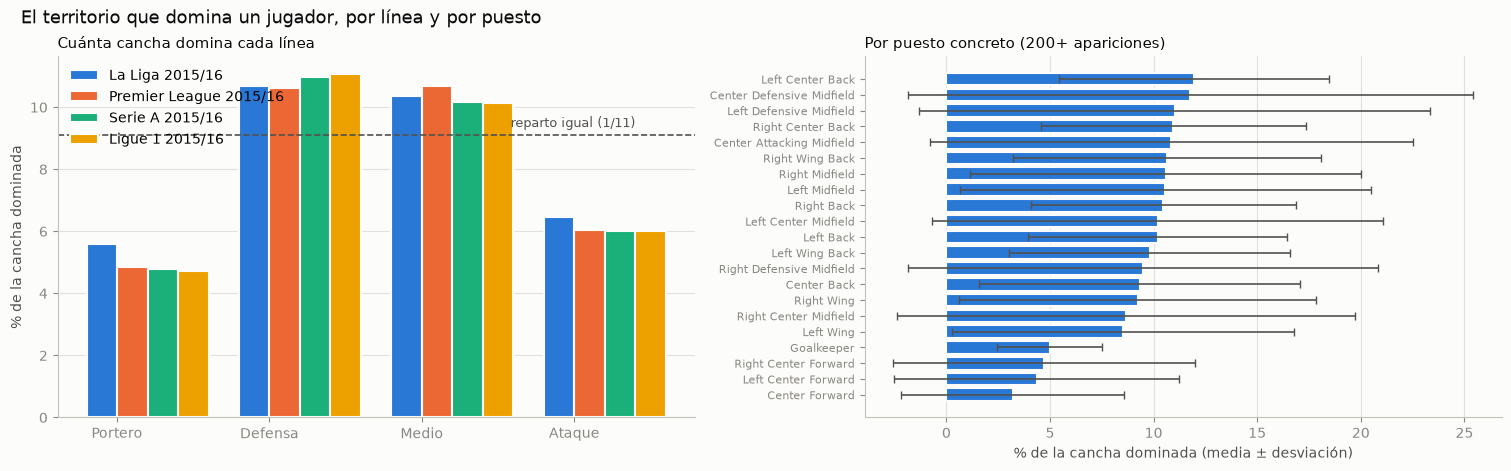

Variación del área explicada por el PUESTO:   9.1%
Variación del área explicada por el JUGADOR:  34.4%  (incluye lo del puesto: casi cada jugador juega siempre en el mismo)


In [6]:
titulares = TODO[TODO["titular"] & TODO["area"].notna()]
por_linea = titulares.groupby(["liga", "linea"])["area"].agg(["mean", "std", "size"]).reset_index()
orden = ["Portero", "Defensa", "Medio", "Ataque"]

fig, axs = plt.subplots(1, 2, figsize=(15, 4.6), constrained_layout=True)
# El ancho y el desplazamiento se calculan a partir de CUÁNTAS ligas hay, no fijos: con el 0.38 pensado para dos
# series, cuatro barras se salían de su grupo e invadían el de al lado.
ancho = 0.8 / len(LIGAS)
centro = (len(LIGAS) - 1) / 2
for k, (nombre, color) in enumerate(zip(LIGAS.values(), estilo.CATEGORICA)):
    d = por_linea[por_linea["liga"] == nombre].set_index("linea").reindex(orden)
    axs[0].bar(np.arange(len(orden)) + (k - 0.5) * ancho, 100 * d["mean"], ancho, color=color, label=nombre,
               edgecolor=estilo.SUPERFICIE, linewidth=1.5)
axs[0].axhline(100 / 11, color=estilo.TINTA_2, linewidth=1.2, linestyle="--")
axs[0].annotate("reparto igual (1/11)", (3.4, 100 / 11), xytext=(0, 6), textcoords="offset points", ha="right",
                fontsize=9, color=estilo.TINTA_2)
axs[0].set_xticks(range(len(orden)), orden)
axs[0].set_ylabel("% de la cancha dominada")
axs[0].set_title("Cuánta cancha domina cada línea")
axs[0].legend()
estilo.rejilla_y(axs[0])

# La dispersión DENTRO de cada puesto: si el área fuera del jugador, dos jugadores del mismo puesto diferirían mucho.
puestos = titulares.groupby("posicion").filter(lambda d: len(d) >= 200)
medias = puestos.groupby("posicion")["area"].mean().sort_values()
axs[1].barh(range(len(medias)), 100 * medias, color=estilo.AZUL, edgecolor=estilo.SUPERFICIE, linewidth=1.5)
axs[1].errorbar(100 * medias, range(len(medias)),
                xerr=100 * puestos.groupby("posicion")["area"].std().reindex(medias.index),
                fmt="none", ecolor=estilo.TINTA_2, elinewidth=1.2, capsize=3)
axs[1].set_yticks(range(len(medias)), medias.index, fontsize=8)
axs[1].set_xlabel("% de la cancha dominada (media ± desviación)")
axs[1].set_title("Por puesto concreto (200+ apariciones)")
axs[1].grid(axis="x", color=estilo.REJILLA, linewidth=0.8)
axs[1].set_axisbelow(True)
fig.suptitle("El territorio que domina un jugador, por línea y por puesto", x=0.01, ha="left", fontsize=13,
             color=estilo.TINTA)
fig.savefig(FIGURAS / "cancha_area_por_puesto.png", dpi=150)
plt.show()

# Qué parte de la variación del área explica el puesto (R² de una regresión sobre las categorías de puesto).
gran_media = titulares["area"].mean()
entre = titulares.groupby("posicion")["area"].transform("mean")
r2_puesto = 1 - ((titulares["area"] - entre) ** 2).sum() / ((titulares["area"] - gran_media) ** 2).sum()
entre_jug = titulares.groupby("player_id")["area"].transform("mean")
r2_jugador = 1 - ((titulares["area"] - entre_jug) ** 2).sum() / ((titulares["area"] - gran_media) ** 2).sum()
print(f"Variación del área explicada por el PUESTO:   {100 * r2_puesto:.1f}%")
print(f"Variación del área explicada por el JUGADOR:  {100 * r2_jugador:.1f}%  "
      f"(incluye lo del puesto: casi cada jugador juega siempre en el mismo)")

Con once jugadores, un reparto perfectamente igual daría 9.1% a cada uno. Lo que sale es que defensas (10.7%) y medios
(10.4%) están por encima, y porteros (5.6%) y atacantes (6.5%) por debajo: entre un delantero y un central hay casi el
doble de terreno dominado.

Los dos R² de abajo hay que leerlos con cuidado:

- El **puesto** explica alrededor del 9% de la variación del área. Poco, y es porque la etiqueta de StatsBomb es muy
  granular: hay quince etiquetas de mediocampista que describen casi lo mismo.
- El **jugador** explica el 35%. Es mucho más, pero está inflado: casi todos juegan siempre en el mismo sitio, así que
  "jugador" lleva "puesto" dentro.
- El **equipo** explica 0%, y eso **no es un hallazgo**: es aritmética. El área se calcula repartiendo la cancha entre
  los once de un mismo equipo, así que las once áreas suman 1 y la media de cualquier equipo es exactamente 1/11. El
  equipo no puede explicar nada por construcción. Se incluye justo para dejarlo dicho y que nadie lo lea como que "la
  forma de jugar del equipo no influye".

### ¿Se repite de un partido al siguiente?

El R² del jugador está inflado: casi todos juegan siempre en el mismo sitio, así que "jugador" arrastra "puesto"
dentro. La forma de separarlos es la misma que este proyecto usó con las porterías a cero: mirar **qué pasa cuando
cambia**. Se emparejan partidos consecutivos del mismo jugador y se separan en tres grados, porque el puesto de
StatsBomb es tan granular que "Right Center Midfield" y "Center Midfield" son etiquetas distintas para casi lo mismo:
mismo puesto exacto, otra etiqueta dentro de la misma línea, o un cambio de línea de verdad.

  grupo  pares  r_mismo_puesto  n_mismo_puesto  r_misma_línea  n_misma_línea  r_cambió_de_línea  n_cambió_de_línea                   liga
Defensa   2881           0.183            2436          0.123            373              0.105                 72        La Liga 2015/16
  Medio   2412           0.308            1146          0.312            996              0.277                270        La Liga 2015/16
Portero    714           0.362             714            NaN              0                NaN                  0        La Liga 2015/16
 Ataque   1802           0.450            1044          0.348            500              0.237                258        La Liga 2015/16
  TODOS   7809           0.353            5340          0.346           1869              0.241                600        La Liga 2015/16
 Ataque   1692           0.430            1013          0.286            406              0.210                273 Premier League 2015/16
  Medio   2536           0.310    

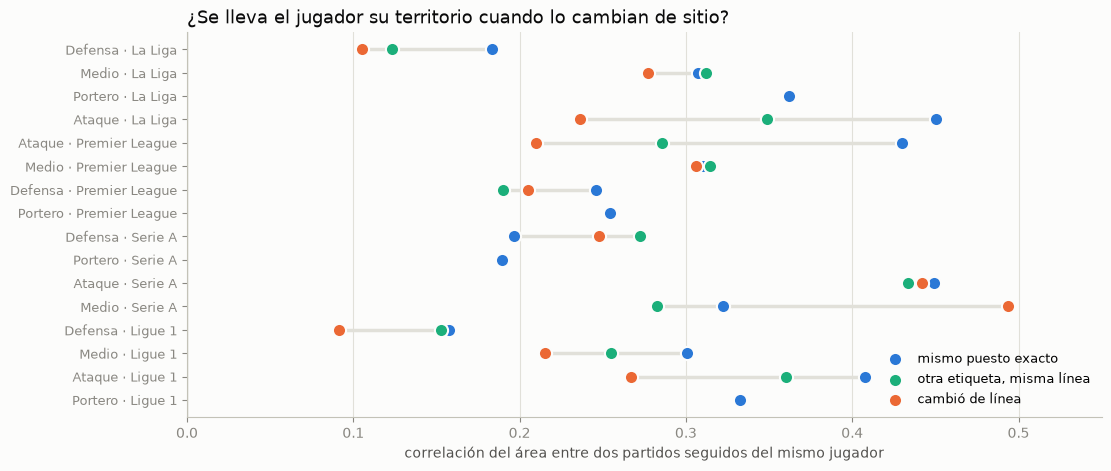

In [7]:
origen = pd.concat([cancha.origen_del_area(posiciones[c], partidos[c]).assign(liga=n)
                    for c, n in LIGAS.items()], ignore_index=True)
print(origen.round(3).to_string(index=False))

grados = [("r_mismo_puesto", "mismo puesto exacto", estilo.AZUL),
          ("r_misma_línea", "otra etiqueta, misma línea", estilo.AQUA),
          ("r_cambió_de_línea", "cambió de línea", estilo.NARANJA)]
resumen = origen[origen["grupo"] != "TODOS"].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(11, 4.6), constrained_layout=True)
y = np.arange(len(resumen))
for i, r in resumen.iterrows():
    valores = [r[c] for c, _, _ in grados if np.isfinite(r[c])]
    if len(valores) > 1:
        ax.plot([min(valores), max(valores)], [i, i], color=estilo.REJILLA, linewidth=2.5, zorder=1)
for col, etiqueta, color in grados:
    ax.scatter(resumen[col], y, s=90, color=color, edgecolors=estilo.SUPERFICIE, linewidths=1.5, zorder=2,
               label=etiqueta)
ax.axvline(0, color=estilo.EJE, linewidth=1)
# El nombre de la liga se corta quitándole la TEMPORADA, no quedándose con la primera palabra: eso daba "La",
# "Serie" y "Ligue", que no son nombres de nada. Todas son 2015/16, así que el año no aporta.
ax.set_yticks(y, [f"{r.grupo} · {r.liga.rsplit(' ', 1)[0]}" for r in resumen.itertuples()], fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, 0.55)
ax.set_xlabel("correlación del área entre dos partidos seguidos del mismo jugador")
ax.grid(axis="x", color=estilo.REJILLA, linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(loc="lower right", fontsize=9)
ax.set_title("¿Se lleva el jugador su territorio cuando lo cambian de sitio?", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / "cancha_estabilidad.png", dpi=150)
plt.show()

De un partido al siguiente el área apenas se repite: **0.35** aun jugando en el mismo puesto exacto. Para comparar,
en este mismo proyecto los goles sin penal por 90 de un delantero se repiten de una temporada a otra con 0.49-0.69.
El territorio de un partido concreto es, en su mayor parte, cosa de ese partido.

El gradiente sí funciona como debería: mismo puesto 0.35, otra etiqueta dentro de la misma línea 0.35 (es decir, esas
etiquetas distinguen poco de verdad) y **cambió de línea 0.24**. Mover a alguien de medio a delantero sí le cambia el
territorio, mover a un "Center Midfield" a "Right Center Midfield" no.

Por líneas aparece algo que parece al revés pero no lo es: los **atacantes** son los más repetibles (0.45) y los
**defensas** los que menos (0.18). No es que los defensas sean más erráticos: es que se parecen mucho entre sí. Todos
los centrales dominan más o menos lo mismo, así que hay poca variación entre jugadores que correlacionar, y el ruido
de partido se come la señal. Entre los atacantes, en cambio, un delantero único y un extremo dominan territorios muy
distintos, y esa diferencia sí sobrevive de un partido al siguiente.

### Lo que un partido no dice, ¿lo dice la temporada?

Que el área de UN partido apenas se repita no significa que la medida sea inútil: puede ser una señal pequeña
enterrada en mucho ruido de partido. La prueba estándar para eso es la **fiabilidad por mitades**: se parten los
partidos de cada jugador en pares e impares, se promedia su área en cada mitad y se correlacionan las dos. La
corrección de Spearman-Brown pasa de "media temporada" a "temporada entera".

Y sobre esa fiabilidad se le van quitando explicaciones alternativas: la media de su puesto, y la media de su equipo
en esa línea. Esta última es el control que faltaba en el análisis de las porterías a cero para no acabar midiendo al
equipo creyendo que se mide al jugador.

                  liga  jugadores  partidos_por_jugador  r_area  r_area_corregida  r_menos_puesto  r_menos_puesto_corregida  r_menos_equipo  r_menos_equipo_corregida  r_menos_equipo_puesto  r_menos_equipo_puesto_corregida
       La Liga 2015/16        334                22.512   0.827             0.906           0.760                     0.863           0.764                     0.866                  0.604                            0.753
Premier League 2015/16        321                23.717   0.817             0.899           0.743                     0.853           0.734                     0.846                  0.497                            0.664
       Serie A 2015/16        336                22.500   0.867             0.929           0.815                     0.898           0.826                     0.904                  0.537                            0.699
       Ligue 1 2015/16        339                21.971   0.815             0.898           0.731               

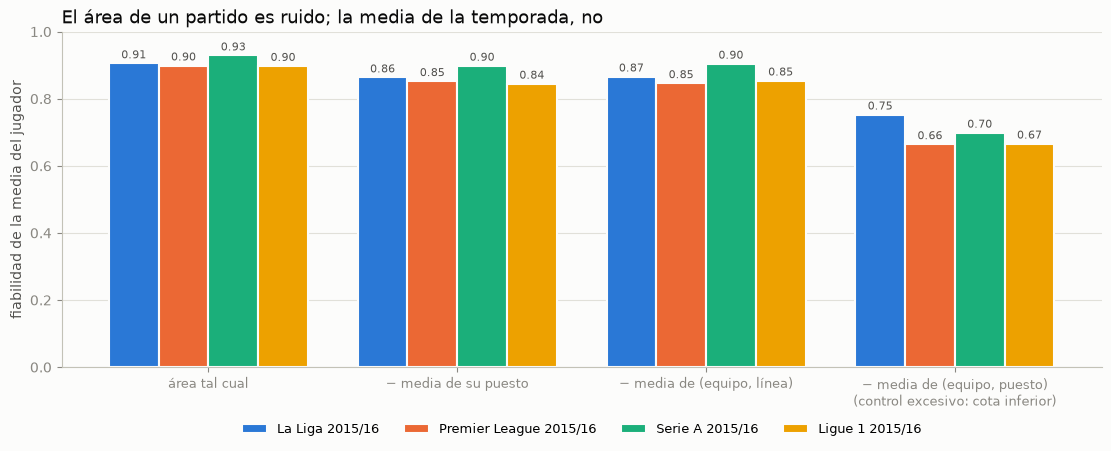

In [8]:
fiabilidad = pd.DataFrame([{"liga": n, **cancha.fiabilidad_del_area(posiciones[c], partidos[c])}
                           for c, n in LIGAS.items()])
print(fiabilidad.round(3).to_string(index=False))

niveles = [("r_area_corregida", "área tal cual"), ("r_menos_puesto_corregida", "− media de su puesto"),
           ("r_menos_equipo_corregida", "− media de (equipo, línea)"),
           ("r_menos_equipo_puesto_corregida", "− media de (equipo, puesto)\n(control excesivo: cota inferior)")]
fig, ax = plt.subplots(figsize=(11, 4.4), constrained_layout=True)
x = np.arange(len(niveles))
# El ancho y el desplazamiento se calculan a partir de CUÁNTAS ligas hay, no fijos: con el 0.38 pensado para dos
# series, cuatro barras se salían de su grupo e invadían el de al lado.
ancho = 0.8 / len(LIGAS)
centro = (len(LIGAS) - 1) / 2
for k, (nombre, color) in enumerate(zip(LIGAS.values(), estilo.CATEGORICA)):
    d = fiabilidad[fiabilidad["liga"] == nombre].iloc[0]
    valores = [d[c] for c, _ in niveles]
    ax.bar(x + (k - centro) * ancho, valores, ancho, color=color, label=nombre, edgecolor=estilo.SUPERFICIE,
           linewidth=1.5)
    for i, v in enumerate(valores):
        ax.text(i + (k - centro) * ancho, v + 0.015, f"{v:.2f}", ha="center", fontsize=8, color=estilo.TINTA_2)
ax.set_xticks(x, [e for _, e in niveles], fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel("fiabilidad de la media del jugador")
# La leyenda va DEBAJO del eje y en horizontal. Dentro del eje tapaba la etiqueta de la primera barra del último
# grupo, y encima chocaba con el título; abajo hay sitio libre y con cuatro ligas cabe en una sola fila.
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=len(LIGAS), fontsize=9, frameon=False)
estilo.rejilla_y(ax)
ax.set_title("El área de un partido es ruido; la media de la temporada, no", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / "cancha_fiabilidad.png", dpi=150, bbox_inches="tight")
plt.show()

Aquí está el resultado importante, y por una vez en este proyecto es positivo.

Aunque el área de un partido suelto sea casi ruido, **la media de un jugador a lo largo de la temporada es muy
fiable**: correlación de **0.90 a 0.93** entre sus partidos pares y sus impares (corregida por Spearman-Brown),
según la liga. Es lo que suele
pasar con las medidas ruidosas pero no vacías: hace falta promediar veinte partidos para que la señal aparezca.

Y sobrevive a los controles, que es lo que decide si mide al jugador o a otra cosa:

- quitándole la media de su **puesto**: 0.85-0.90
- quitándole además la media de su **equipo en esa línea**: 0.85-0.90
- con el control excesivo de (equipo, puesto exacto): 0.66-0.75

Que las cuatro ligas den lo mismo importa más que el número concreto: son cuatro campeonatos de cuatro países con
estilos distintos, y en los cuatro la medida se comporta igual. Serie A sale la más alta (0.93) y Ligue 1 la más
baja (0.90), una diferencia pequeña al lado de lo que separa a esta métrica del resto del proyecto.

Ese último se reporta como **cota inferior** porque se pasa de frenada: en la mitad de los casos ese puesto de ese
equipo lo ocupó casi siempre la misma persona, así que restarle la media de la celda es restarle su propia señal.

La conclusión es entonces bastante firme: **dos jugadores del mismo puesto y del mismo equipo dominan cantidades de
territorio distintas, y lo hacen de forma consistente toda la temporada.** Es la primera métrica de este proyecto que
pasa la prueba de "¿mide al jugador?" con holgura — y conviene recordar que lo que mide es participación con éxito
repartida en el espacio, no calidad.

## 4. Los equipos: ¿quién reparte mejor su cancha?

Con el mapa se puede medir algo que no estaba en ninguna tabla: qué tan **concentrado** está el dominio territorial de
un equipo. Un equipo donde un jugador se queda con el 25% de la cancha reparte distinto que uno donde nadie pasa del
12%.

2,881 equipos-partido con los once completos
                        mayor_celda   gini
liga                                      
La Liga 2015/16               0.279  0.461
Ligue 1 2015/16               0.282  0.462
Premier League 2015/16        0.287  0.469
Serie A 2015/16               0.292  0.477

Puntos medios por partido según lo concentrado del dominio (cuartiles del índice de Gini):
                 mean  size
gini                       
más repartido    1.66   716
2                1.42   716
3                1.30   715
más concentrado  1.17   716


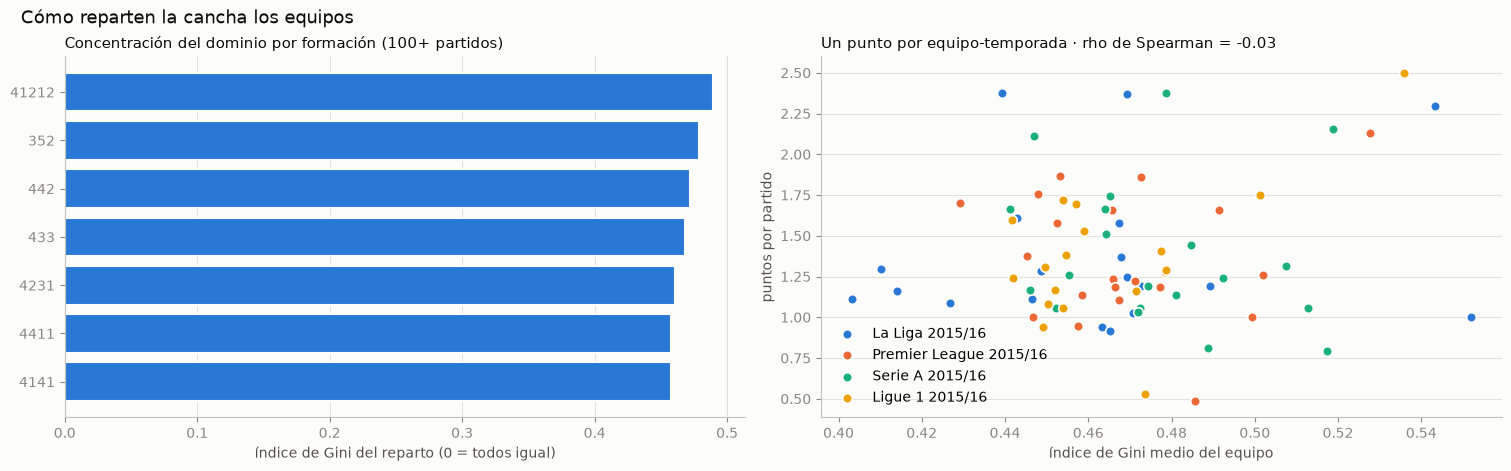

In [9]:
reparto = pd.concat([cancha.reparto_por_equipo(posiciones[c]).assign(liga=n) for c, n in LIGAS.items()],
                    ignore_index=True)
reparto = reparto[reparto["jugadores"] == 11]
print(f"{len(reparto):,} equipos-partido con los once completos")
print(reparto.groupby("liga")[["mayor_celda", "gini"]].mean().round(3).to_string())

# ¿Repartir mejor la cancha va con ganar? Se une el marcador del partido.
marcadores = pd.concat([partidos[c].assign(liga=n) for c, n in LIGAS.items()], ignore_index=True)
local = marcadores.rename(columns={"home_team": "team", "home_score": "goles", "away_score": "recibidos"})
visita = marcadores.rename(columns={"away_team": "team", "away_score": "goles", "home_score": "recibidos"})
resultados = pd.concat([local[["match_id", "team", "goles", "recibidos"]],
                        visita[["match_id", "team", "goles", "recibidos"]]], ignore_index=True)
r = reparto.merge(resultados, on=["match_id", "team"])
r["puntos"] = np.where(r["goles"] > r["recibidos"], 3, np.where(r["goles"] == r["recibidos"], 1, 0))
print(f"\nPuntos medios por partido según lo concentrado del dominio (cuartiles del índice de Gini):")
print(r.groupby(pd.qcut(r["gini"], 4, labels=["más repartido", "2", "3", "más concentrado"]),
                observed=True)["puntos"].agg(["mean", "size"]).round(2).to_string())

fig, axs = plt.subplots(1, 2, figsize=(15, 4.6), constrained_layout=True)
formaciones = reparto.groupby("formacion").filter(lambda d: len(d) >= 100)
med = formaciones.groupby("formacion")["gini"].mean().sort_values()
axs[0].barh(range(len(med)), med, color=estilo.AZUL, edgecolor=estilo.SUPERFICIE, linewidth=1.5)
axs[0].set_yticks(range(len(med)), med.index)
axs[0].set_xlabel("índice de Gini del reparto (0 = todos igual)")
axs[0].set_title("Concentración del dominio por formación (100+ partidos)")
axs[0].grid(axis="x", color=estilo.REJILLA, linewidth=0.8)
axs[0].set_axisbelow(True)

equipos_top = r.groupby(["liga", "team"]).agg(gini=("gini", "mean"), ppg=("puntos", "mean"),
                                              n=("puntos", "size")).reset_index()
equipos_top = equipos_top[equipos_top["n"] >= 30]
for nombre, color in zip(LIGAS.values(), estilo.CATEGORICA):
    d = equipos_top[equipos_top["liga"] == nombre]
    axs[1].scatter(d["gini"], d["ppg"], s=48, color=color, edgecolors=estilo.SUPERFICIE, linewidths=1.2, label=nombre)
rho = equipos_top["gini"].corr(equipos_top["ppg"], method="spearman")
axs[1].set(xlabel="índice de Gini medio del equipo", ylabel="puntos por partido")
axs[1].set_title(f"Un punto por equipo-temporada · rho de Spearman = {rho:.2f}")
axs[1].legend()
estilo.rejilla_y(axs[1])
fig.suptitle("Cómo reparten la cancha los equipos", x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / "cancha_equipos.png", dpi=150)
plt.show()

El dominio territorial está muy concentrado: en el equipo medio, el jugador que más domina se queda con el 28-29% de
la cancha y el índice de Gini del reparto va de 0.46 a 0.48, casi idéntico en las cuatro ligas. Otra vez manda el peso, así que esto
mide cuánto concentra un equipo su participación, no su dibujo táctico.

Y aquí aparece la relación más fuerte del notebook, que conviene mirar con cuidado precisamente por eso: del cuartil
de equipos-partido **más repartidos** al **más concentrados**, los puntos por partido caen de **1.66 a 1.17**. Es
medio punto por partido, un gradiente limpio y monótono en los cuatro cuartiles.

**No hay que leerlo como que repartir la cancha hace ganar.** La causa más probable va justo al revés: un equipo que
domina el partido tiene más balón, y con más balón participan más jugadores y el reparto se iguala solo. Es decir,
"repartir" es en buena medida un síntoma de estar dominando, no su causa. La correlación entre equipos-temporada
—que promedia ese efecto de partido— es bastante más floja que el gradiente por partido, lo cual encaja con esa
lectura.

Dicho eso, la cifra sirve como descripción: los partidos en los que un equipo concentra su juego en un solo jugador
son, sistemáticamente, partidos que le salen peor.

## 5. Conclusiones

1. **Los diagramas de Apolonio funcionan igual de bien sobre la cancha que en el espacio de perfil**, y aquí ni
   siquiera hace falta normalizar los ejes: los dos están en metros. El módulo `futbol_bd/cancha.py` reutiliza sin
   cambios la maquinaria de `apolonio.py` del notebook 17.

2. **La posición media engaña si se mira sola.** Las elipses de dispersión cubren un tercio de la cancha: el mapa
   resume dónde tuvo cada jugador su centro de gravedad, no por dónde anduvo.

3. **El peso manda sobre la geometría.** Con acciones exitosas como peso, el jugador más participativo se lleva hasta
   el 28% de la cancha. El mapa es de territorio de participación, no de ocupación ni de calidad.

4. **El área de un partido suelto es casi ruido** (0.35 de un partido al siguiente, contra 0.49-0.69 de una medida
   individual establecida). Cambiar de línea la baja a 0.24; cambiar de etiqueta dentro de la misma línea no cambia
   nada, porque esas etiquetas distinguen poco.

5. **Pero la media de la temporada sí mide al jugador**, y con holgura: fiabilidad de 0.90-0.93 en las cuatro ligas,
   que se queda en 0.85-0.90 al quitar el puesto y en 0.85-0.90 al quitar además al equipo. Dos jugadores del mismo puesto ocupan consistentemente
   territorios distintos. Es el resultado más sólido de los que ha dado este proyecto sobre una métrica individual.

6. **Un detalle metodológico que vale la pena guardar**: el R² del equipo salió 0% y eso no significa nada, porque las
   áreas suman 1 dentro de cada equipo. Cuando una métrica se define como un reparto, los efectos del grupo
   desaparecen por construcción y hay que buscarlos de otra forma.

**Lo que queda fuera**: sin datos de seguimiento óptico no hay velocidades, así que esto no es la *dominant region* de
Taki y Hasegawa —que responde "quién llega antes a cada punto"— sino su versión posible con eventos. Y el mapa reparte
la cancha entre los once de un mismo equipo; cruzar los 22 de los dos equipos respondería otra pregunta y necesitaría
justo esas velocidades que no hay.